gen: 0, fitness: 125
gen: 50, fitness: 143
gen: 100, fitness: 160
gen: 150, fitness: 160


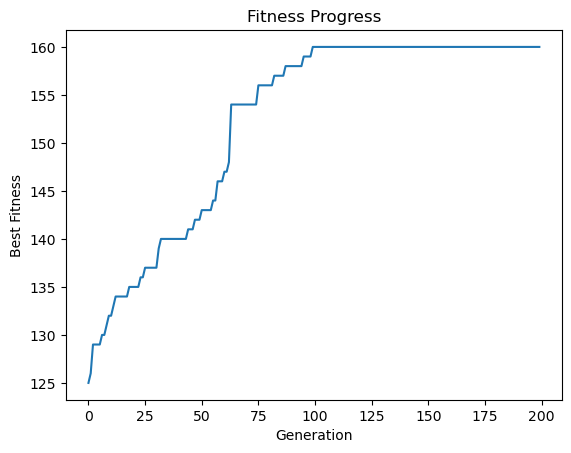

Initial:
[0, 0, 0, 0, 0, 1, 4, 0, 0]
[0, 8, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 5, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 7, 2, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 9, 0, 0]
[0, 0, 3, 9, 0, 0, 0, 0, 8]

Best Fitness: 160

Solution:
[3, 6, 9, 8, 5, 1, 4, 7, 2]
[4, 8, 5, 3, 2, 7, 6, 1, 9]
[7, 1, 2, 4, 6, 9, 8, 3, 5]
[8, 3, 7, 6, 9, 5, 2, 4, 1]
[1, 5, 6, 2, 3, 4, 7, 8, 9]
[9, 2, 4, 7, 1, 8, 3, 5, 6]
[6, 9, 8, 1, 7, 2, 5, 3, 4]
[2, 4, 1, 5, 8, 3, 9, 6, 7]
[5, 7, 3, 9, 4, 6, 1, 2, 8]


In [123]:
import random
import matplotlib.pyplot as plt
import numpy as np

import random

def is_valid(grid, row, col, num):
    if num in grid[row]:  # Check row
        return False
    for r in range(9):  # Check column
        if grid[r][col] == num:
            return False
    start_row, start_col = 3 * (row // 3), 3 * (col // 3)  # Check 3x3 subgrid
    for i in range(3):
        for j in range(3):
            if grid[start_row + i][start_col + j] == num:
                return False
    return True

def generate_initial_sudoku(filled_cells=10):
    # Start with empty 9x9 grid
    grid = [[0] * 9 for _ in range(9)]
    cells = [(i, j) for i in range(9) for j in range(9)]
    random.shuffle(cells)  # Randomize cell order
    
    count = 0
    for row, col in cells:
        if count >= filled_cells:  # Stop when desired number of cells are filled
            break
        nums = random.sample(range(1, 10), 9)  # Try numbers 1-9 in random order
        for num in nums:
            if is_valid(grid, row, col, num):
                grid[row][col] = num
                count += 1
                break  # Move to next cell after placing a number
    
    return grid

def create_individual(initial_sudoku):
    individual = []
    for row in initial_sudoku:
        fixed = [num for num in row if num != 0]
        remaining = [num for num in range(1, 10) if num not in fixed]
        np.random.shuffle(remaining)
        new_row = []
        idx = 0
        for num in row:
            new_row.append(num if num != 0 else remaining[idx])
            idx += 1 if num == 0 else 0
        individual.append(new_row)
    return individual

def initialize_population(initial_sudoku, population_size):
    return [create_individual(initial_sudoku) for _ in range(population_size)]

def fitness(individual):
    column_unique = sum(len(set(col)) for col in zip(*individual))
    subgrid_unique = 0
    for i in range(0, 9, 3):
        for j in range(0, 9, 3):
            subgrid = [individual[x][y] for x in range(i, i+3) for y in range(j, j+3)]
            subgrid_unique += len(set(subgrid))
    return column_unique + subgrid_unique

def sus_selection(population, fitnesses, num_parents):
    sorted_pop = sorted(zip(population, fitnesses), key=lambda x: -x[1])
    population_sorted = [x[0] for x in sorted_pop]
    ranks = list(range(len(population_sorted), 0, -1))
    total_rank = sum(ranks)
    probs = [r / total_rank for r in ranks]
    cum_probs = np.cumsum(probs).tolist()
    step = 1.0 / num_parents
    start = random.uniform(0, step)
    pointers = [(start + i * step) % 1 for i in range(num_parents)]
    selected = []
    for ptr in pointers:
        idx = 0
        while idx < len(cum_probs) and cum_probs[idx] < ptr:
            idx += 1
        selected.append(population_sorted[min(idx, len(population_sorted)-1)])
    return selected

def crossover(parent1, parent2):
    return [parent1[i] if random.random() < 0.5 else parent2[i] for i in range(9)]

def mutate(individual, initial_sudoku, mutation_rate=0.1):
    mutated = [row.copy() for row in individual]
    for i in range(9):
        if random.random() < mutation_rate:
            non_fixed = [j for j in range(9) if initial_sudoku[i][j] == 0]
            if len(non_fixed) >= 2:
                j1, j2 = random.sample(non_fixed, 2)
                mutated[i][j1], mutated[i][j2] = mutated[i][j2], mutated[i][j1]
    return mutated

def genetic_algorithm(initial_sudoku, population_size=1000, max_generations=1000, elitism_size=100, mutation_rate=0.2, stagnation_limit=100):
    population = initialize_population(initial_sudoku, population_size)
    best_fitness = 0
    best_individual = None
    fitness_history = []
    stagnation = 0

    for gen in range(max_generations):
        fitnesses = [fitness(ind) for ind in population]
        current_best = max(fitnesses)
        if current_best > best_fitness:
            best_fitness = current_best
            best_individual = population[fitnesses.index(current_best)]
            stagnation = 0
        else:
            stagnation += 1
        
        if gen%50==0:
            print(f"gen: {gen}, fitness: {current_best}")
        fitness_history.append(current_best)

        if best_fitness == 162 or stagnation >= stagnation_limit:
            break

        parents = sus_selection(population, fitnesses, population_size - elitism_size)
        offspring = []
        while len(offspring) < len(parents):
            p1, p2 = random.sample(parents, 2)
            child = crossover(p1, p2)
            child = mutate(child, initial_sudoku, mutation_rate)
            offspring.append(child)
        
        elites = sorted(zip(population, fitnesses), key=lambda x: -x[1])[:elitism_size]
        elites = [e[0] for e in elites]
        population = elites + offspring

    plt.plot(fitness_history)
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness')
    plt.title('Fitness Progress')
    plt.show()

    return best_individual, best_fitness

initial_sudoku = generate_initial_sudoku(filled_cells=10)
best_solution, best_fitness = genetic_algorithm(initial_sudoku)

print("Initial:")
for row in initial_sudoku:
    print(row)
print()
print(f"Best Fitness: {best_fitness}")
print()
print("Solution:")
for row in best_solution:
    print(row)